In [6]:
trajectory_folderpath = "/app/aaa/data/raw_data/all_data/put_the_blue_cube_in_the_red_cup/success/2026-03-02/Mon_Mar__2_16:11:33_2026"
h5_filepath = trajectory_folderpath + "/trajectory.h5"
recording_folderpath="/app/data/success/2026-03-02/Mon_Mar__2_16:11:33_2026/recordings/MP4"

In [7]:
import time
from collections import defaultdict
from copy import deepcopy

import cv2
import numpy as np
from PIL import Image

from droid.calibration.calibration_utils import *
from droid.camera_utils.info import camera_type_to_string_dict
from droid.camera_utils.wrappers.recorded_multi_camera_wrapper import RecordedMultiCameraWrapper
from droid.misc.parameters import *
from droid.misc.time import time_ms
from droid.misc.transformations import change_pose_frame
from droid.trajectory_utils.trajectory_reader import TrajectoryReader
from droid.trajectory_utils.trajectory_writer import TrajectoryWriter

In [8]:
def load_trajectory(
        filepath=None,
        read_cameras=True,
        recording_folderpath=None,
        camera_kwargs={},
        remove_skipped_steps=False,
        num_samples_per_traj=None,
        num_samples_per_traj_coeff=1.5,
):
    read_hdf5_images = read_cameras and (recording_folderpath is None)
    read_recording_folderpath = read_cameras and (recording_folderpath is not None)

    traj_reader = TrajectoryReader(filepath, read_images=read_hdf5_images)
    if read_recording_folderpath:
        camera_reader = RecordedMultiCameraWrapper(recording_folderpath, camera_kwargs)

    horizon = traj_reader.length()
    timestep_list = []

    # Choose Timesteps To Save #
    if num_samples_per_traj:
        num_to_save = num_samples_per_traj
        if remove_skipped_steps:
            num_to_save = int(num_to_save * num_samples_per_traj_coeff)
        max_size = min(num_to_save, horizon)
        indices_to_save = np.sort(np.random.choice(horizon, size=max_size, replace=False))
    else:
        indices_to_save = np.arange(horizon)

    # Iterate Over Trajectory #
    for i in indices_to_save:
        # Get HDF5 Data #
        timestep = traj_reader.read_timestep(index=i)

        # If Applicable, Get Recorded Data #
        if read_recording_folderpath:
            timestamp_dict = timestep["observation"]["timestamp"]["cameras"]
            camera_type_dict = {
                k: camera_type_to_string_dict[v] for k, v in timestep["observation"]["camera_type"].items()
            }
            camera_obs = camera_reader.read_cameras(
                index=i, camera_type_dict=camera_type_dict, timestamp_dict=timestamp_dict
            )
            camera_failed = camera_obs is None

            # Add Data To Timestep If Successful #
            if camera_failed:
                break
            else:
                timestep["observation"].update(camera_obs)

        # Filter Steps #
        step_skipped = not timestep["observation"]["controller_info"].get("movement_enabled", True)
        delete_skipped_step = step_skipped and remove_skipped_steps

        # Save Filtered Timesteps #
        if delete_skipped_step:
            del timestep
        else:
            timestep_list.append(timestep)

    # Remove Extra Transitions #
    timestep_list = np.array(timestep_list)
    if (num_samples_per_traj is not None) and (len(timestep_list) > num_samples_per_traj):
        ind_to_keep = np.random.choice(len(timestep_list), size=num_samples_per_traj, replace=False)
        timestep_list = timestep_list[ind_to_keep]

    # Close Readers #
    traj_reader.close()

    # Return Data #
    return timestep_list

In [9]:
data = load_trajectory(h5_filepath, recording_folderpath=recording_folderpath)

In [13]:
print(len(data))

221


In [15]:
data[0].keys()

dict_keys(['action', 'observation'])

In [16]:
data[0]['action'].keys()


dict_keys(['cartesian_position', 'cartesian_velocity', 'gripper_position', 'gripper_velocity', 'joint_position', 'joint_velocity', 'robot_state', 'target_cartesian_position', 'target_gripper_position'])

In [17]:
data[0]['observation'].keys()

dict_keys(['camera_extrinsics', 'camera_intrinsics', 'camera_type', 'controller_info', 'robot_state', 'timestamp', 'image'])

In [21]:
data[0]['observation']['camera_type']


{'17967083': 0, '31780776': 1, '36064187': 1}

In [18]:
data[0]['observation']['robot_state'].keys()

dict_keys(['cartesian_position', 'gripper_position', 'joint_positions', 'joint_torques_computed', 'joint_velocities', 'motor_torques_measured', 'prev_command_successful', 'prev_controller_latency_ms', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened'])

In [19]:
data[0]['observation']['image'].keys()


dict_keys(['36064187_left', '36064187_right', '31780776_left', '31780776_right', '17967083_left', '17967083_right'])

In [25]:
data[0]['observation']['image']['36064187_left'].shape


(720, 640, 3)

In [27]:
data[0]['observation']['image']['36064187_left'].max()


255

In [26]:
data[0]['observation']['image']['36064187_left'].min()

0

In [28]:
data[0]['observation']['image']['36064187_left'].mean()

89.5424537037037

In [29]:
data[0]['observation']['image']['36064187_left'].var()

4243.804618400634

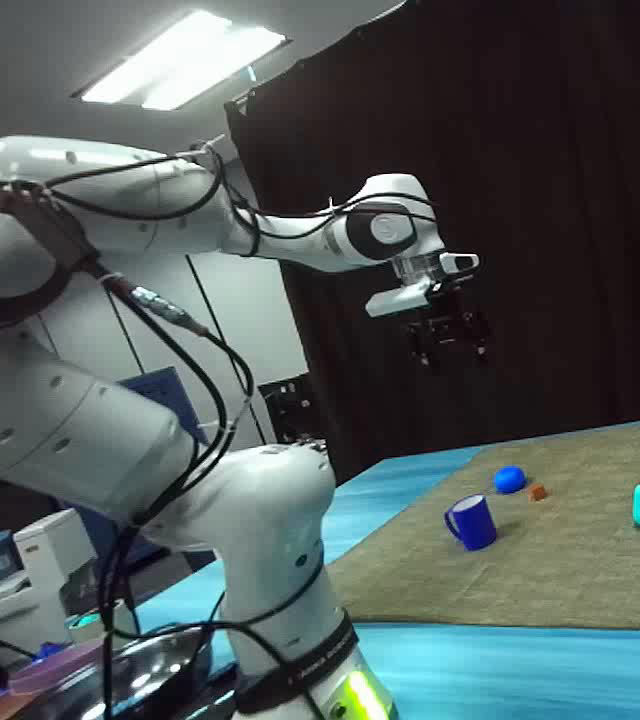

In [39]:
show_image = Image.fromarray(data[0]['observation']['image']['36064187_left'])
show_image

In [31]:
def _resize_and_encode(image, size):
    image = Image.fromarray(image)
    return np.array(image.resize(size, resample=Image.BICUBIC))

In [32]:
IMAGE_RES = (180, 320)

resize_image = _resize_and_encode(data[0]['observation']['image']['36064187_left'] , (IMAGE_RES[1], IMAGE_RES[0]))

In [33]:
resize_image.shape

(180, 320, 3)

In [34]:
resize_image.max()

255

In [35]:
resize_image.min()

0

In [36]:
resize_image.mean()

89.53774884259259

In [37]:
resize_image.var()

4138.700091228586

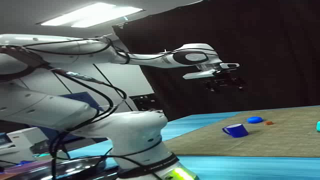

In [40]:
resize_image_show = Image.fromarray(resize_image)
resize_image_show

In [46]:
data[0]['observation']['image']['17967083_left'].shape


(720, 640, 3)

In [47]:
data[0]['observation']['image']['17967083_left'].mean()


111.2086595775463

In [48]:
data[0]['observation']['image']['17967083_left'].var()


2186.5599804225963

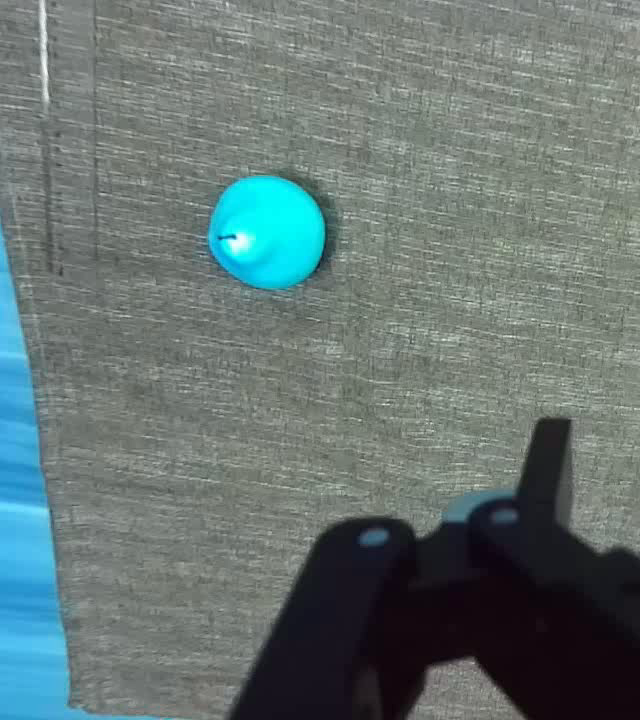

In [49]:
Image.fromarray(data[0]['observation']['image']['17967083_left'])

In [50]:
resize_image_wrist = _resize_and_encode(data[0]['observation']['image']['17967083_left'],(IMAGE_RES[1], IMAGE_RES[0]))

In [51]:
resize_image_wrist.shape

(180, 320, 3)

In [52]:
resize_image_wrist.mean()

111.20880208333334

In [53]:
resize_image_wrist.var()

2115.3728658103655

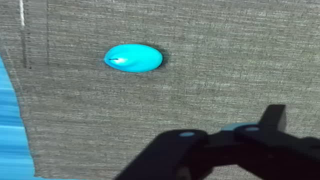

In [54]:
Image.fromarray(resize_image_wrist)

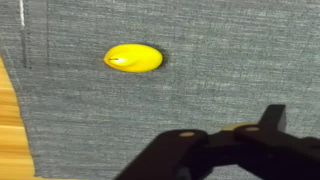

In [55]:
Image.fromarray(resize_image_wrist[..., ::-1])

In [56]:
data[0]['observation']['robot_state'].keys()

dict_keys(['cartesian_position', 'gripper_position', 'joint_positions', 'joint_torques_computed', 'joint_velocities', 'motor_torques_measured', 'prev_command_successful', 'prev_controller_latency_ms', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened'])

In [58]:
data[0]['observation']['robot_state']['joint_positions']
#[ 0.0180, -0.6926, -0.1878, -2.4668, -0.0184,  1.9020, -0.3091,  0.0000]

array([ 0.01800841, -0.6926409 , -0.18777452, -2.46676326, -0.01837285,
        1.90200365, -0.30914086])

In [59]:
data[50]['observation']['robot_state']['joint_positions']
# [ 0.0286,  0.0937,  0.0178, -1.9255, -0.1204,  1.9535, -0.1180,  0.0000]

array([ 0.02855293,  0.09371606,  0.01783506, -1.92553377, -0.12043503,
        1.95351672, -0.11800704])

In [60]:
data[200]['observation']['robot_state']['joint_positions']
# [ 0.0959, -0.0555,  0.1128, -2.1780,  0.1832,  1.9665, -0.2860,  0.0000]


array([ 0.09592854, -0.05549438,  0.11284655, -2.17801499,  0.18319309,
        1.96647334, -0.2859638 ])

In [3]:
recording_folderpath="/app/data/success/2026-03-02/Mon_Mar__2_16:11:33_2026/recordings/MP4"
camera_kwargs={}
camera_reader = RecordedMultiCameraWrapper(recording_folderpath, camera_kwargs)

In [4]:
camera_reader

In [ ]:
camera_obs = camera_reader.read_cameras(
    index=0, camera_type_dict=camera_type_dict, timestamp_dict=timestamp_dict
)

In [19]:
# Prepare Trajectory Reader #
traj_reader = TrajectoryReader(h5_filepath, read_images=False)
horizon = traj_reader.length()

# ================= 新增：初始化用于保存 action 的列表 =================
saved_actions = []

saved_states = []

for i in range(horizon):
    # Get HDF5 Data #
    timestep = traj_reader.read_timestep()
    # print(timestep.keys())
    # print(timestep["observation"].keys())
    # print(timestep["observation"]["robot_state"].keys())

    timestamp_dict = timestep["observation"]["timestamp"]["cameras"]
    camera_type_dict = {
        k: camera_type_to_string_dict[v] for k, v in timestep["observation"]["camera_type"].items()
    }
    camera_obs = camera_reader.read_cameras(
        index=i, camera_type_dict=camera_type_dict, timestamp_dict=timestamp_dict
    )
    camera_failed = camera_obs is None

    # Add Data To Timestep If Successful #
    if camera_failed:
        break
    else:
        timestep["observation"].update(camera_obs)

    # breakpoint()
    # Move To Initial Position #
    if i == 0:
        init_joint_position = timestep["observation"]["robot_state"]["joint_positions"]
        init_gripper_position = timestep["observation"]["robot_state"]["gripper_position"]
        action = np.concatenate([init_joint_position, [init_gripper_position]])
        print(f"init_action:{action}")

    state_joint_position = timestep["observation"]["robot_state"]["joint_positions"]
    state_gripper_position = timestep["observation"]["robot_state"]["gripper_position"]
    state = np.concatenate([state_joint_position, [state_gripper_position]])
    saved_states.append(state.tolist())

    # # Regularize Control Frequency #
    # time.sleep(1 / env.control_hz)

    # Get Action In Desired Action Space #
    arm_action = timestep["action"]["joint_velocity"]
    gripper_action = timestep["action"]["gripper_position"]
    action = np.concatenate([arm_action, [gripper_action]])
    controller_info = timestep["observation"]["controller_info"]
    movement_enabled = controller_info.get("movement_enabled", True)
    
    # if "velocity" in env.action_space:
    #     # clip all dimensions of action to [-1, 1]
    #     action = np.clip(action, -1, 1)        
        
    # ================= 新增：将 numpy array 转为 list 并追加到保存列表中 =================
    saved_actions.append(action.tolist())
    
    # Follow Trajectory #
    # print(f"Step {i}: {action}")
    # if movement_enabled:
    #     env.step(action)

dict_keys(['action', 'observation'])
dict_keys(['camera_extrinsics', 'camera_intrinsics', 'camera_type', 'controller_info', 'robot_state', 'timestamp'])
dict_keys(['cartesian_position', 'gripper_position', 'joint_positions', 'joint_torques_computed', 'joint_velocities', 'motor_torques_measured', 'prev_command_successful', 'prev_controller_latency_ms', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened'])
init_action:[ 0.01800841 -0.6926409  -0.18777452 -2.46676326 -0.01837285  1.90200365
 -0.30914086  0.        ]
dict_keys(['action', 'observation'])
dict_keys(['camera_extrinsics', 'camera_intrinsics', 'camera_type', 'controller_info', 'robot_state', 'timestamp'])
dict_keys(['cartesian_position', 'gripper_position', 'joint_positions', 'joint_torques_computed', 'joint_velocities', 'motor_torques_measured', 'prev_command_successful', 'prev_controller_latency_ms', 'prev_joint_torques_computed', 'prev_joint_torques_computed_safened'])
dict_keys(['action', 'observation'])
di

In [13]:
import matplotlib.pyplot as plt

def plot_action_dimensions(actions):
    """
    绘制 actions 数组中每一维随 step i 的变化曲线，
    每一维单独一个子图。
    
    参数:
        actions: numpy.ndarray 或 torch.Tensor，形状 (N, D)
                 N 是步数，D 是维度数
    """
    # 如果是 torch.Tensor，转成 numpy
    
    # if hasattr(actions, 'numpy'):
    #     actions = actions.numpy()
    actions = np.array(actions)
    num_dims = actions.shape[1]
    fig, axes = plt.subplots(num_dims, 1, figsize=(12, 2*num_dims), sharex=True)

    for dim in range(num_dims):
        axes[dim].plot(range(actions.shape[0]), actions[:, dim])
        axes[dim].set_ylabel(f'Dim {dim}')
        axes[dim].grid(True)

    axes[-1].set_xlabel('Step i')
    fig.suptitle('Action vector dimensions over steps')
    plt.tight_layout()
    plt.show()


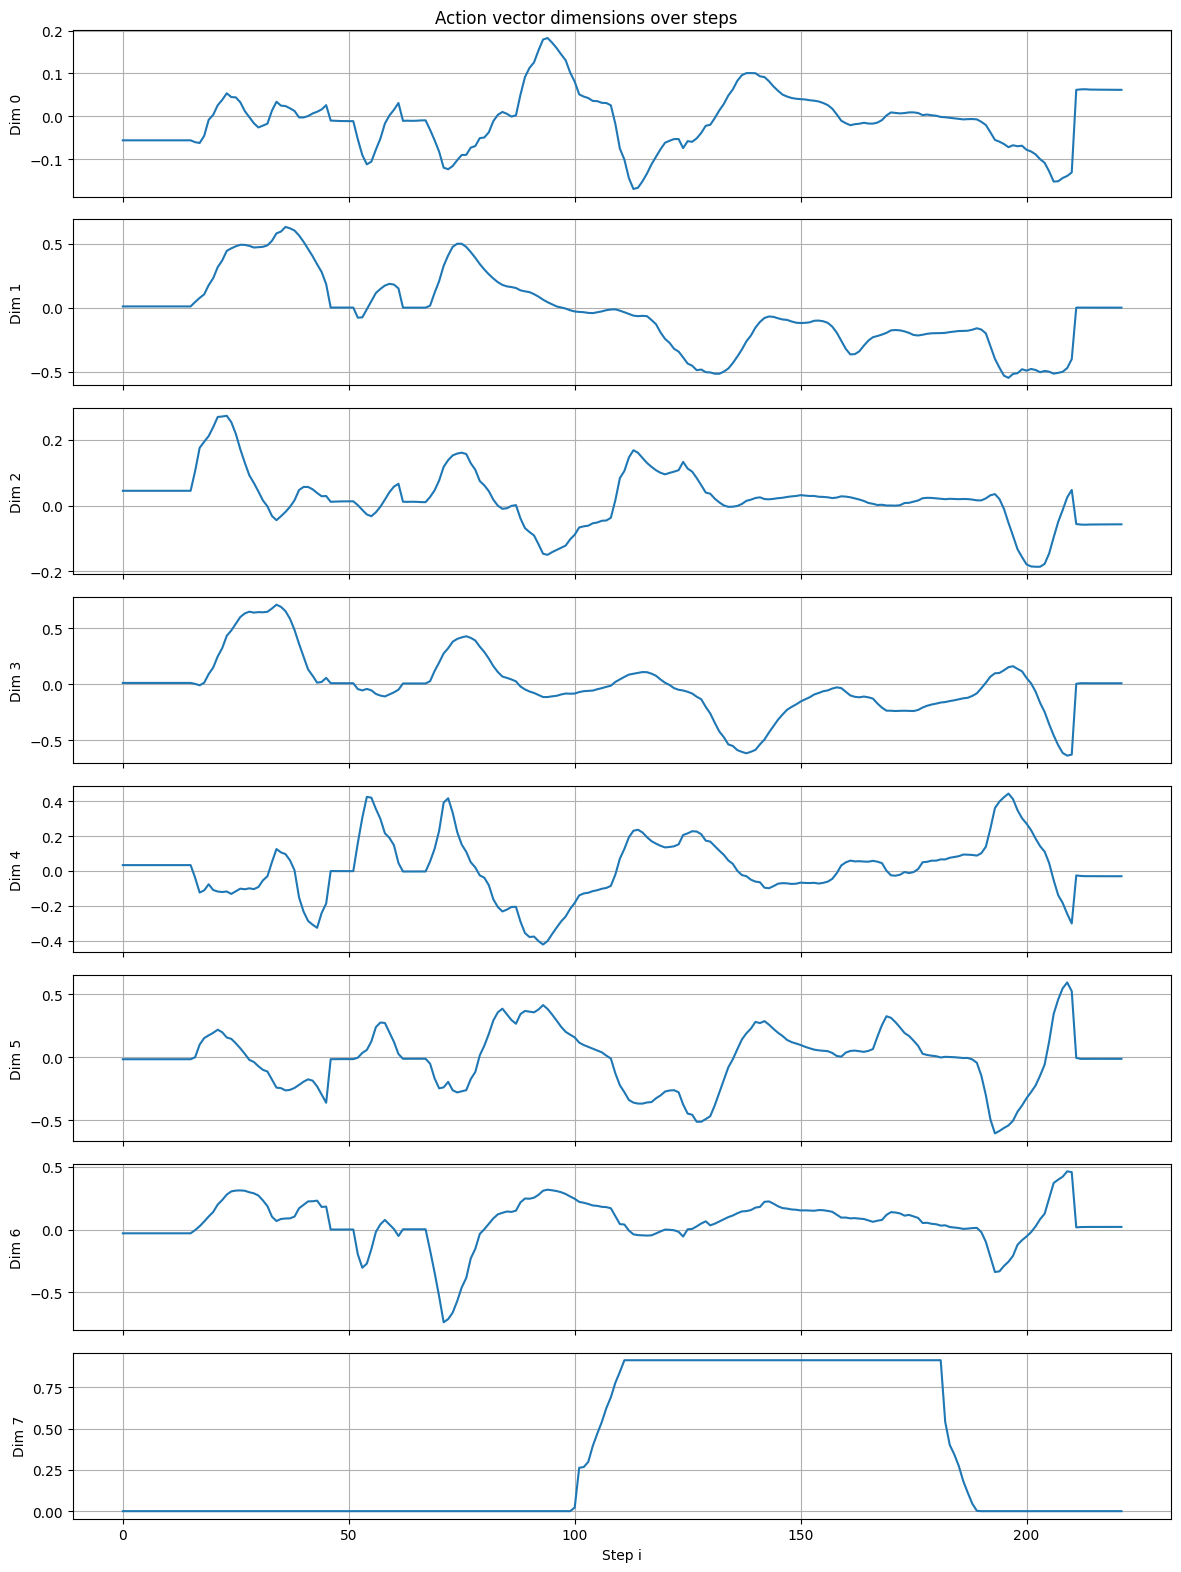

In [14]:
plot_action_dimensions(saved_actions)

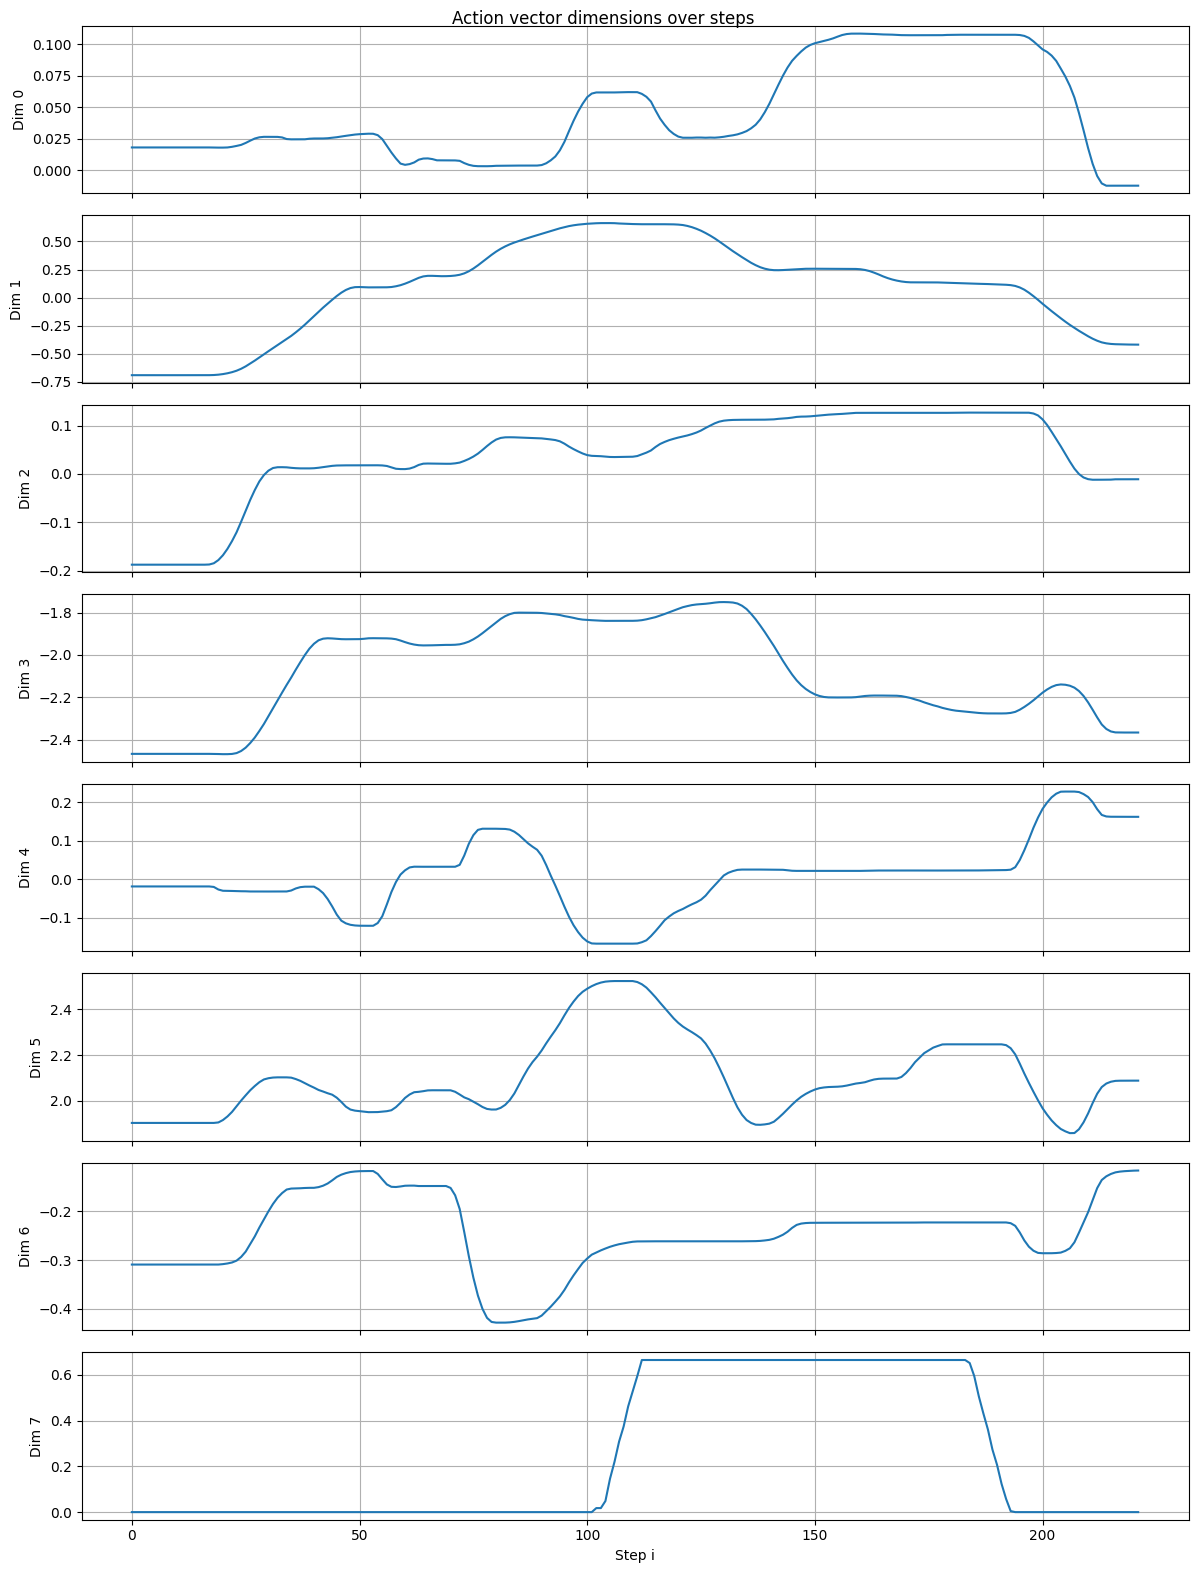

In [15]:
plot_action_dimensions(saved_states)
